### ![alt text](https://nexteducacion.com/wp-content/uploads/2020/02/cropped-next-educaci%C3%B3n.png.webp "nextEDUCACION")
### Máster en Big Data y Business Intelligence.

### Obtencion de Datos para el TFM.
**Autores**
- David Mejía Cascante
- Daniel Vargas Salazar
- Juan Luis Chávez Mejía
- María Cubero Sandoval
- Melany Jiménez Nin

### Asignatura 7. Modelado Predictivo con Machine Learning
### **Profesor: **
### Fecha: 28 de Marzo del 2026.

## 1. Selección del dataset

Se ha elegido, High overcommitment and low reward as potential predictors for increased depressive symptoms, suicidal ideation, and suicide risk in German veterinarians, este data set no cuenta un API para su llamado.

**Dataset:** https://www.ebi.ac.uk/biostudies/europepmc/studies/S-EPMC11421818

## 2. Objetivos.

Objetivos

## 3. Limpieza y preparación de los datos

### A. Preparacion del entorno y librerias necesarias.

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

url = 'https://raw.githubusercontent.com/davidmejiacascante/next_a7/main/data/Veterinarians%20In%20germany.xlsx'
df = pd.read_excel(url, engine='openpyxl')

### B. Cargar los datos del dataset.

In [158]:
print("Cantidad de datos y dimensiones en el data set de Netflix: ",df.shape)

Cantidad de datos y dimensiones en el data set de Netflix:  (3179, 57)


In [159]:
print("Resumen del data set, variables, cantidad de nulos y tipos de datos: ")
df.info()

Resumen del data set, variables, cantidad de nulos y tipos de datos: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3179 entries, 0 to 3178
Data columns (total 57 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   SBQR 1_attempt                            3153 non-null   float64
 1   SBQR 2_frequency                          3153 non-null   float64
 2   SBQR 3_thread                             3153 non-null   float64
 3   SBQR4_likelihood                          3153 non-null   float64
 4   SBQ_SUMN                                  3153 non-null   float64
 5   SBQ_CUTN                                  3153 non-null   float64
 6   ERI_1                                     3178 non-null   float64
 7   ERI_2                                     3178 non-null   float64
 8   ERI_3                                     3178 non-null   float64
 9   ERI_4                                

In [160]:
df = df.drop_duplicates().copy()
df.shape

(3179, 57)

In [161]:
print("Observaciones:", df.shape[0])

Observaciones: 3179


In [162]:
print("Variables:", df.shape[1])

Variables: 57


In [163]:
print("Lista de variables:", list(df.columns))

Lista de variables: ['SBQR 1_attempt', 'SBQR 2_frequency', 'SBQR 3_thread', 'SBQR4_likelihood', 'SBQ_SUMN', 'SBQ_CUTN', 'ERI_1', 'ERI_2', 'ERI_3', 'ERI_4', 'ERI_5', 'ERI_6', 'ERI_7', 'ERI_8', 'ERI_9', 'ERI_10', 'COPSOQ_B1 (quantitative demands)', 'B2', 'B3', 'B4', 'COPSOQ_emotional demands (ED)_01', 'ED_02', 'ED_03', 'COPSOQ_demands_for_hiding_emotions (DHD)', 'DHD_02', 'COPSQO work-privacy-conlfict (wpc)_01', 'WPC_02', 'WPC_03', 'WPC_4', 'WPC_05', 'COPSOQ B10', 'CBI_01', 'CBI_02', 'CBI_03', 'CBI_04', 'CBI_05', 'CBI_06', 'COPSOQ-meaning_of_work-(mow)_01', 'mow_02', 'mow_03', 'PHQ9_01', 'PHQ9_02', 'PHQ9_03', 'PHQ9_04', 'PHQ9_05', 'PHQ9_06', 'PHQ9_07', 'PHQ9_08', 'PHQ9_09', 'gender', 'birth year', 'status of employment', 'field of work', 'federal state', 'community size', 'income', 'working hours']


In [164]:
print("Valores nulos en el dataset: ")
df.isna().sum().sort_values(ascending=False)

Valores nulos en el dataset: 


,0
working hours,53
SBQR 2_frequency,26
SBQR 3_thread,26
SBQR4_likelihood,26
SBQ_SUMN,26
SBQ_CUTN,26
SBQR 1_attempt,26
birth year,9
community size,4
income,4


In [165]:
print("Eliminar valores nulos.")
df = df.dropna()

Eliminar valores nulos.


In [166]:
print("Valores duplicados en el dataset: ",df.duplicated().sum())

Valores duplicados en el dataset:  0


### C. Revisión de tipos de datos y columnas.

Eliminar las columnas que no se usaran para el TFM.

In [167]:
df = df.drop(columns=["SBQR 1_attempt","SBQR 2_frequency","SBQR 3_thread","SBQR4_likelihood","SBQ_SUMN","SBQ_CUTN","COPSOQ-meaning_of_work-(mow)_01","mow_02","mow_03","PHQ9_01","PHQ9_02","PHQ9_03","PHQ9_04","PHQ9_05","PHQ9_06","PHQ9_07","PHQ9_08","PHQ9_09"])
df.head()

,ERI_1,ERI_2,ERI_3,ERI_4,ERI_5,ERI_6,ERI_7,ERI_8,ERI_9,ERI_10,...,CBI_05,CBI_06,gender,birth year,status of employment,field of work,federal state,community size,income,working hours
0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,2.0,2.0,1.0,...,4.0,3.0,2.0,1986,9.0,12.0,-2.0,2.0,1.0,60
1,2.0,2.0,2.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,...,2.0,1.0,2.0,1980,2.0,9.0,4.0,2.0,3.0,35
2,3.0,3.0,3.0,3.0,2.0,2.0,1.0,3.0,3.0,3.0,...,4.0,3.0,2.0,1989,2.0,9.0,4.0,1.0,3.0,42
3,3.0,4.0,4.0,1.0,2.0,2.0,2.0,2.0,2.0,3.0,...,4.0,2.0,2.0,1984,2.0,5.0,4.0,3.0,3.0,45
4,3.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0,3.0,3.0,...,1.0,1.0,1.0,1978,2.0,2.0,4.0,4.0,2.0,40


In [168]:
# --------------------------------------------
# CÓDIGOS ESPECIALES
# (-1, -2, -9 como missing)
# --------------------------------------------
df = df.replace([-1, -2, -9], np.nan)

### E. Feature engineering.

In [169]:
# ------------------------------------------------------------
# VARIABLE OBJETIVO
# ------------------------------------------------------------
df['burn_out_score'] = df[['CBI_01','CBI_02','CBI_03','CBI_04','CBI_05','CBI_06']].mean(axis=1)

In [170]:
# ------------------------------------------------------------
# Columna "working hours"
# ------------------------------------------------------------
def clean_working_hours(value):

    if pd.isna(value):   # Si es na, retorna NAN
        return np.nan

    value = str(value).lower().strip()

    # categorias invalidas
    invalid_keywords = [
        "rentner", "retired", "teilzeit", "part-time",
        "unterschiedlich", "selbst", "ständig",
        "rufbereitschaft"
    ]
    if any(k in value for k in invalid_keywords):  # Si es texto, retorna NAN
        return np.nan

    # normalizar separadores
    value = value.replace(",", ".")
    value = value.replace("–", "-")

    # Rangos: "35-40", "45 - 55". retorna el promedio.
    range_match = re.findall(r"(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)", value)
    if range_match:
        low, high = map(float, range_match[0])
        return (low + high) / 2

    # mayor a
    gt_match = re.findall(r"(?:>|mindestens|min\.?)\s*(\d+(?:\.\d+)?)", value)
    if gt_match:
        return float(gt_match[0])

    # Aproximado
    approx_match = re.findall(r"(?:ca\.?|etwa)\s*(\d+(?:\.\d+)?)", value)
    if approx_match:
        return float(approx_match[0])

    # numero entero
    num_match = re.findall(r"\d+(?:\.\d+)?", value)
    if num_match:
        return float(num_match[0])

    return np.nan

df["working hours"] = df["working hours"].apply(clean_working_hours)

#valores no reales
df.loc[df["working hours"] > 100, "working hours"] = np.nan
df.loc[df["working hours"] < 5, "working hours"] = np.nan


In [171]:
print("Eliminar valores nulos.")
df = df.dropna()

Eliminar valores nulos.


## 4. Analisis exploratorio de datos (EDA).

### 4.1 Análisis univariante:

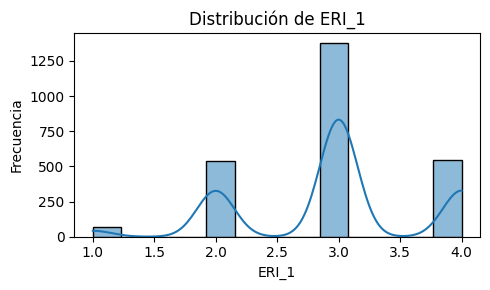

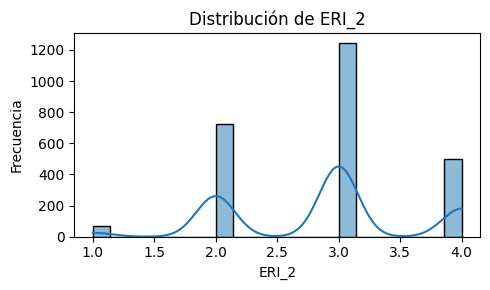

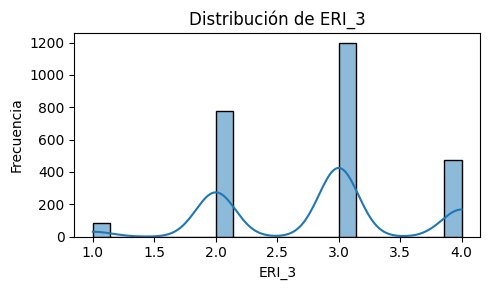

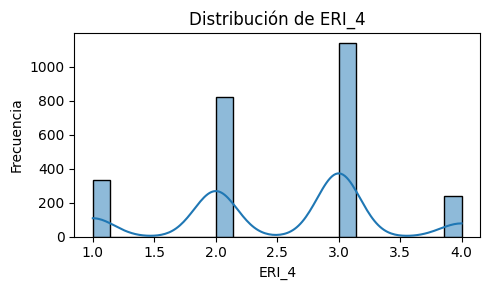

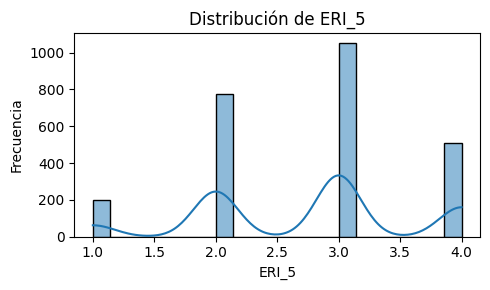

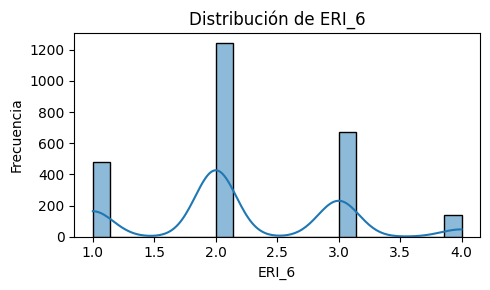

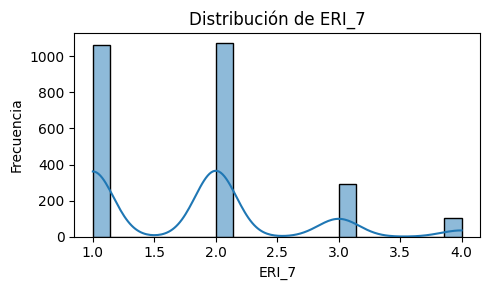

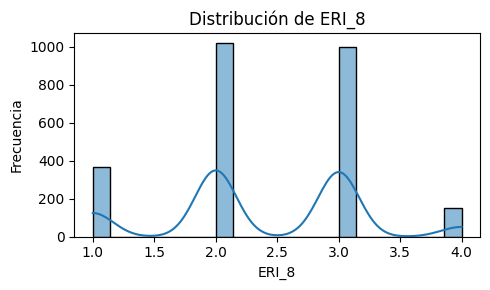

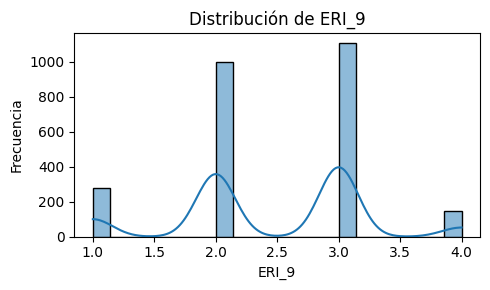

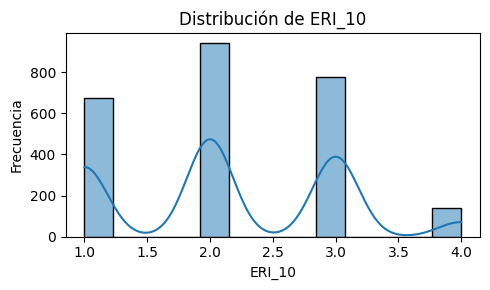

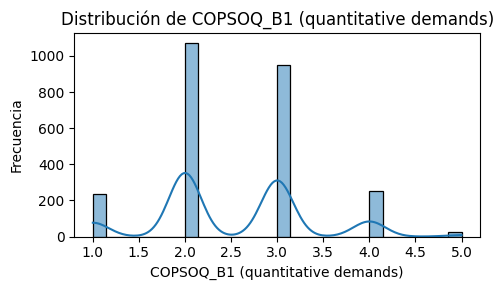

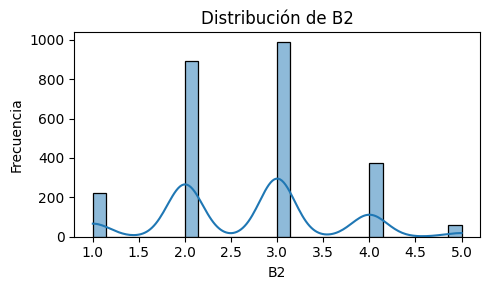

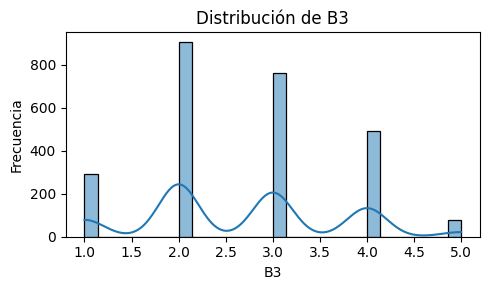

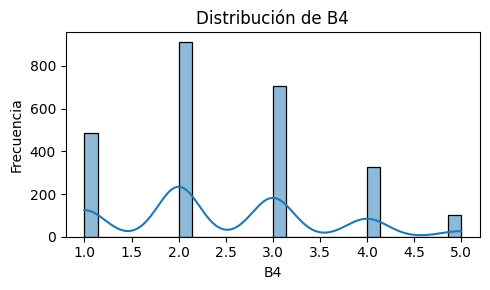

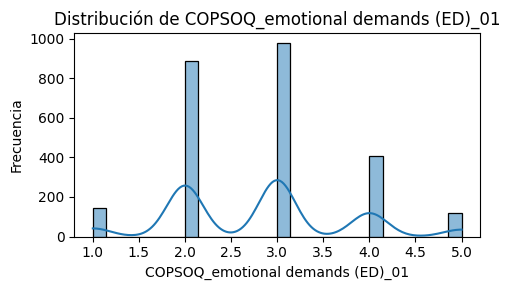

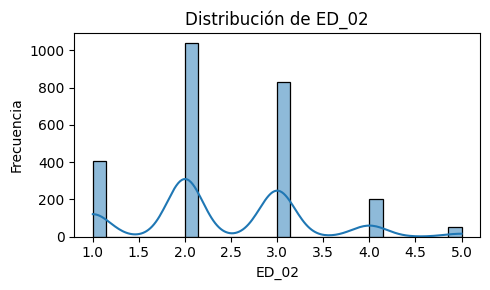

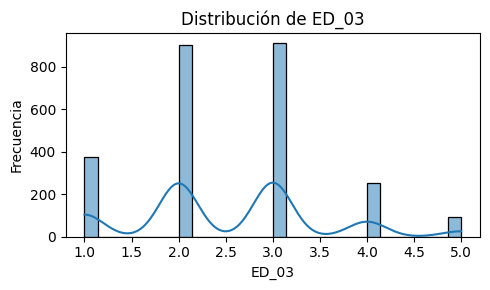

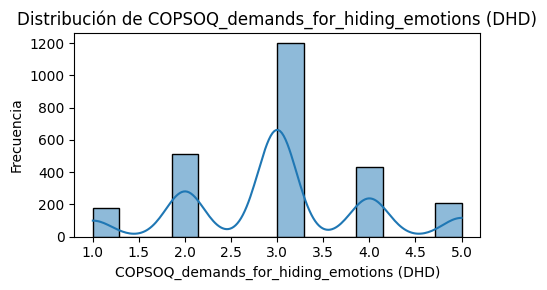

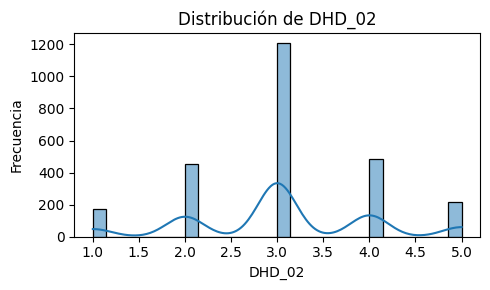

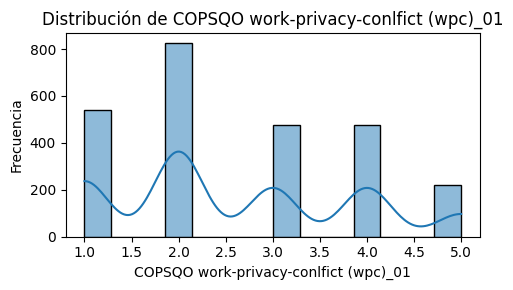

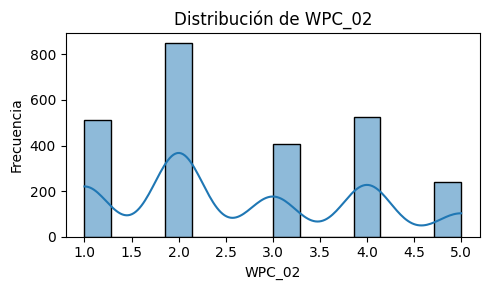

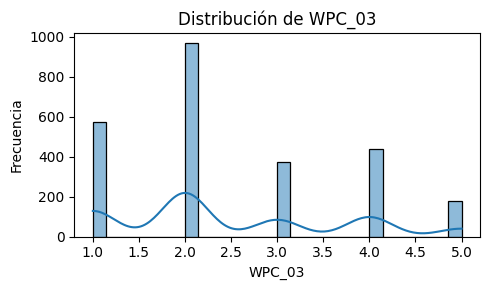

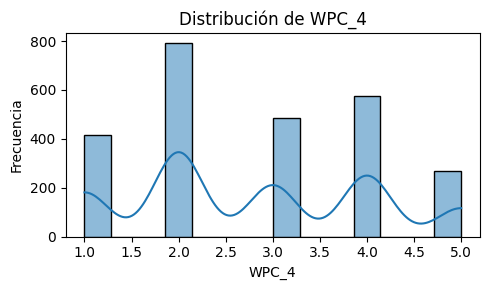

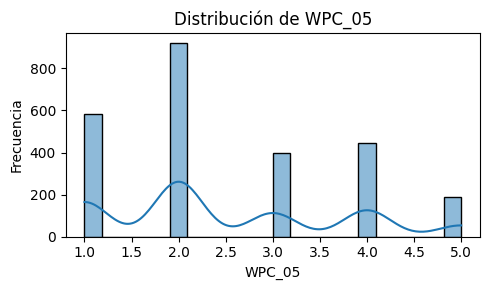

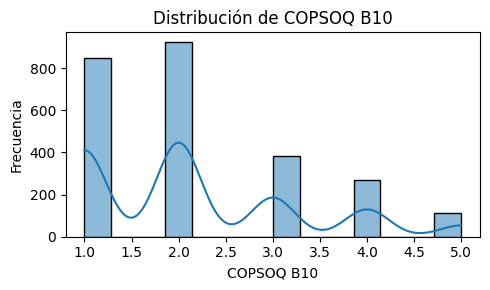

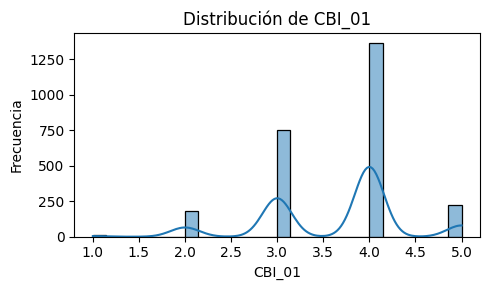

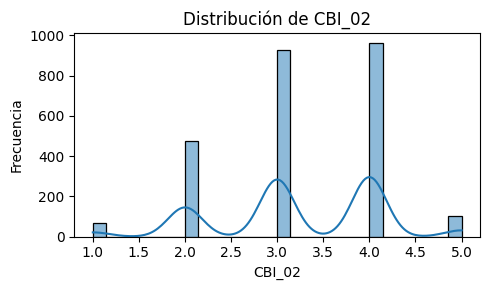

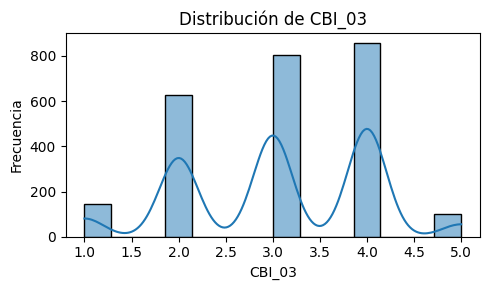

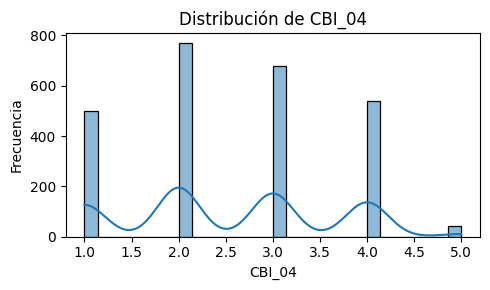

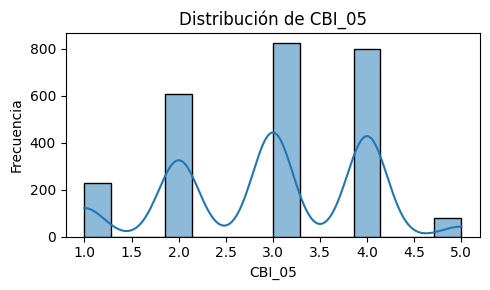

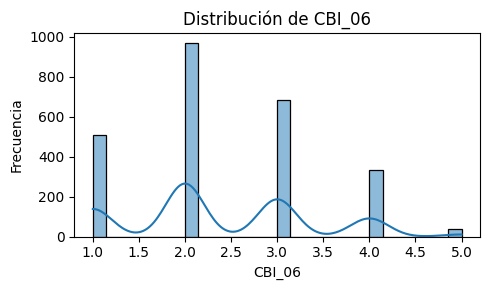

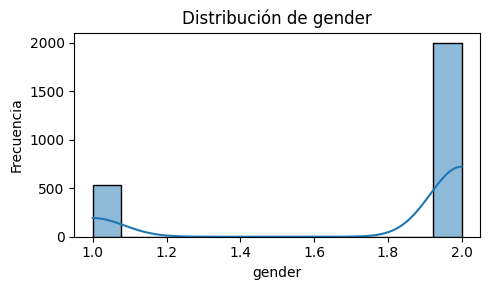

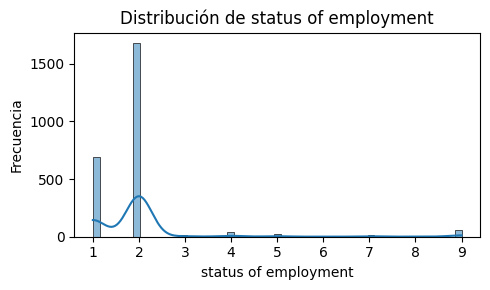

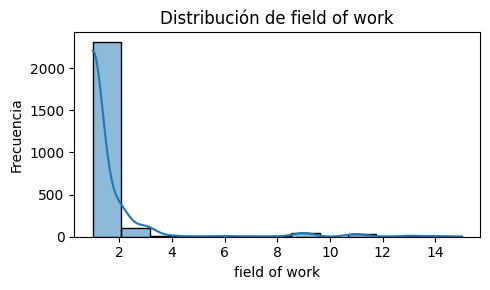

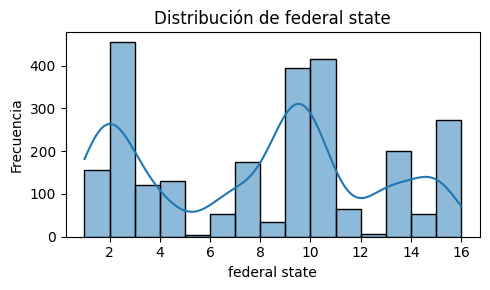

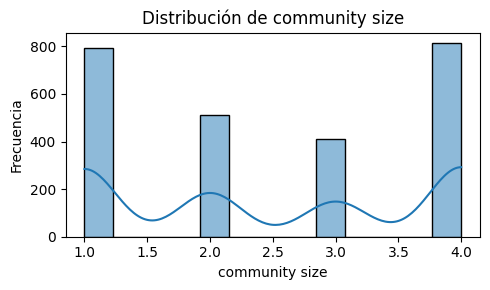

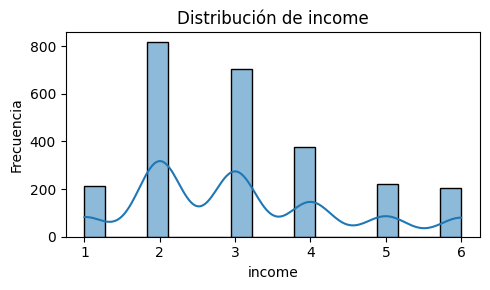

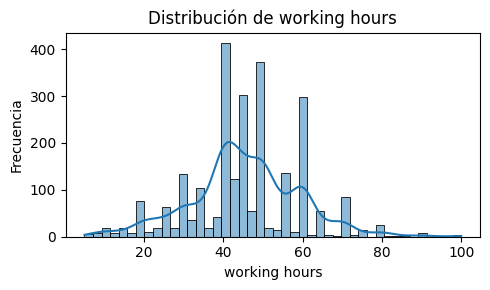

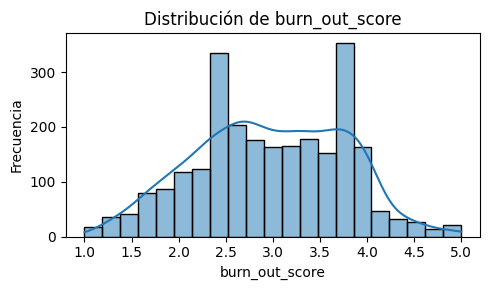

In [172]:
# --------------------------------------------
# DISTRIBUCIONES UNIVARIANTES
# --------------------------------------------
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

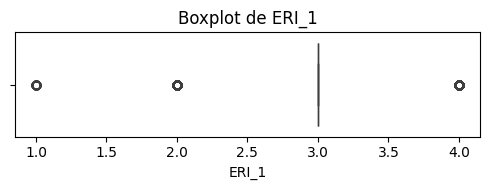

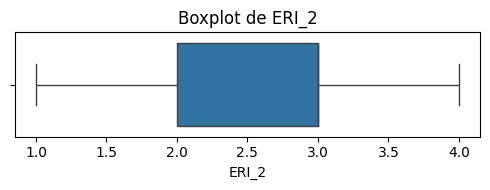

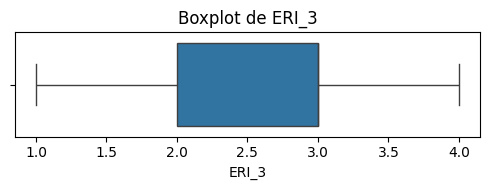

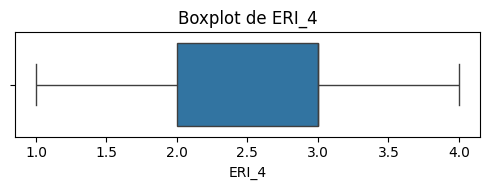

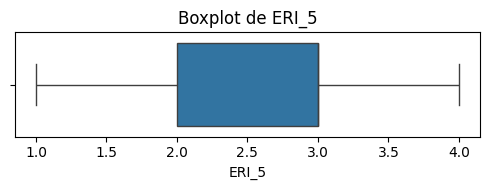

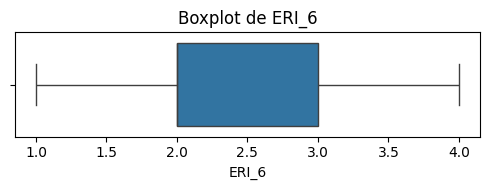

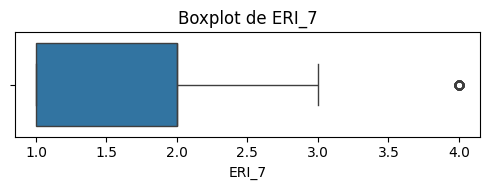

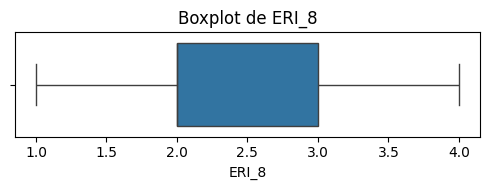

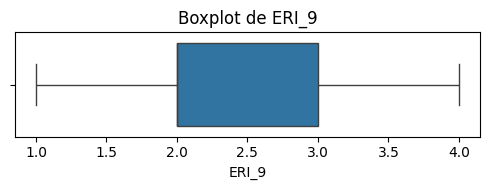

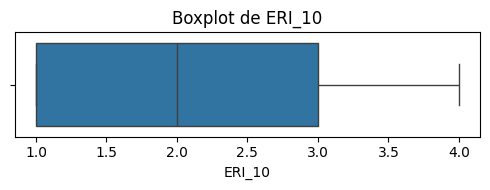

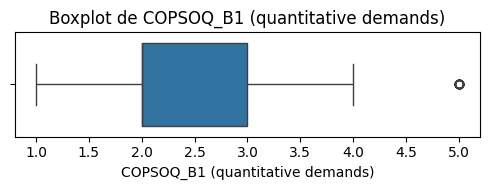

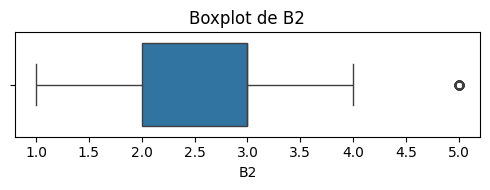

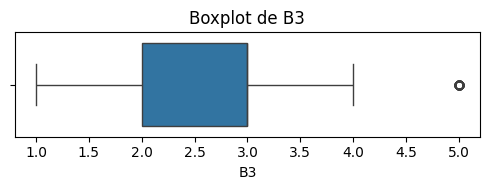

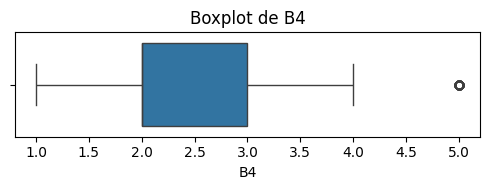

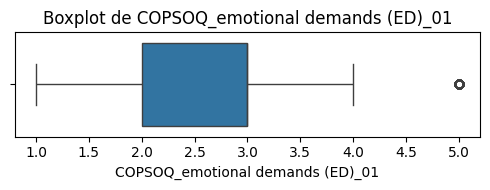

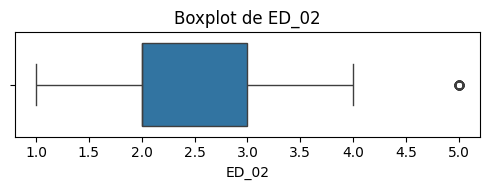

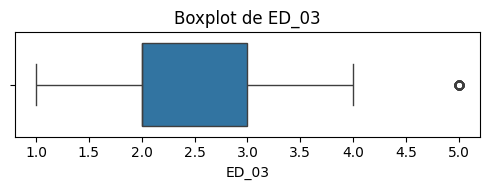

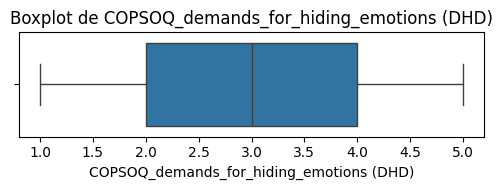

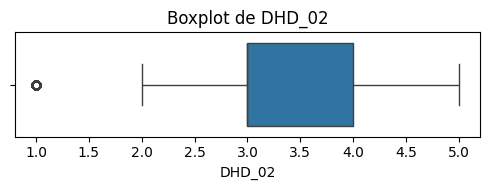

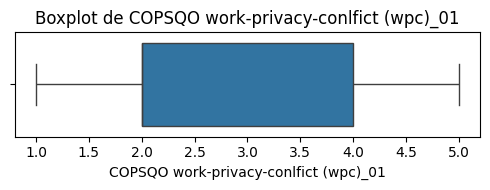

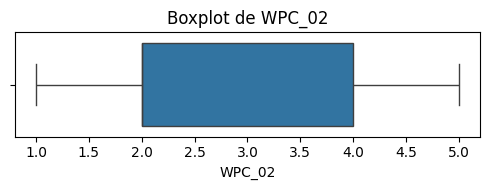

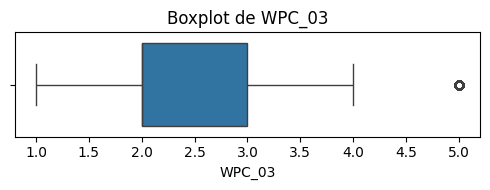

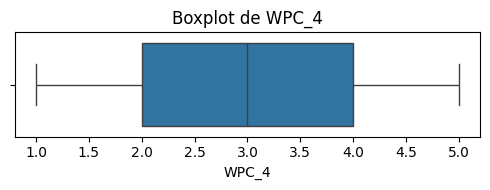

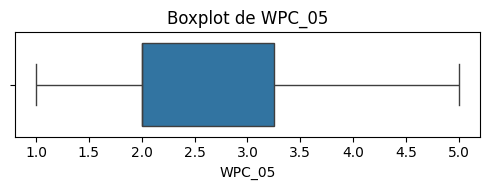

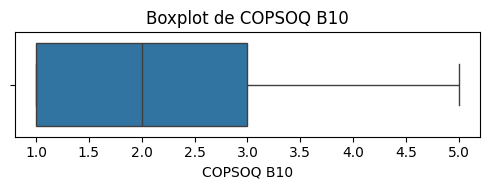

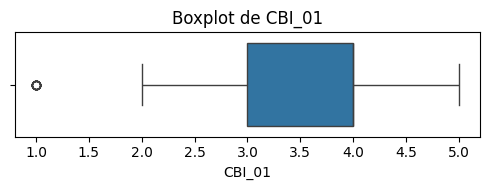

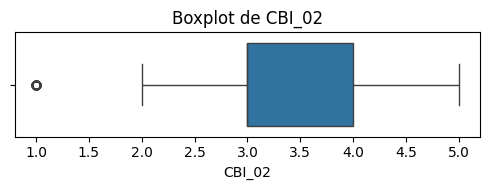

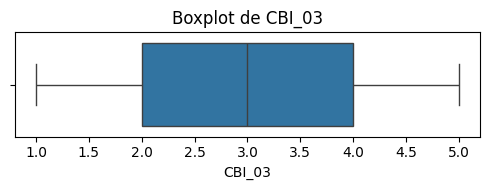

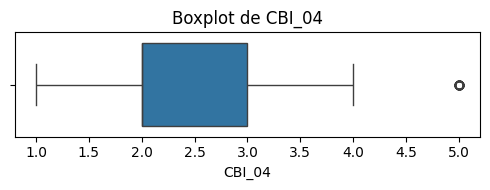

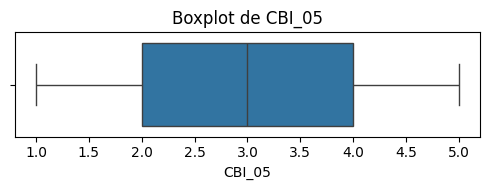

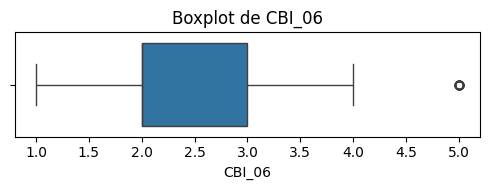

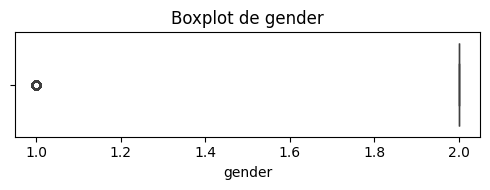

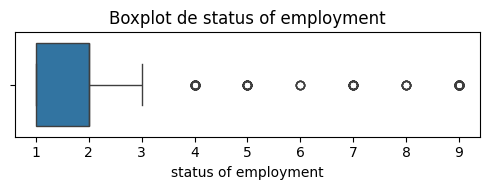

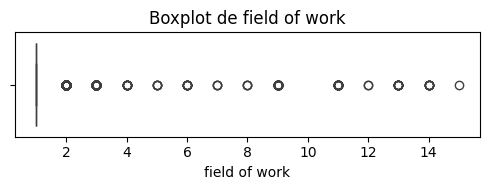

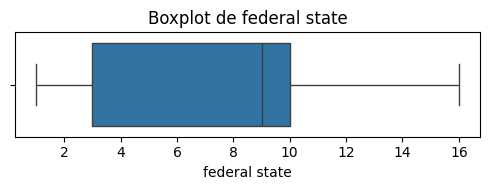

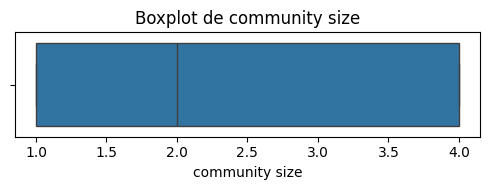

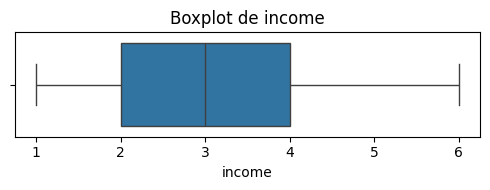

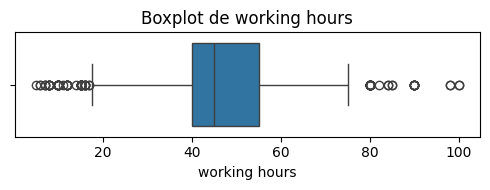

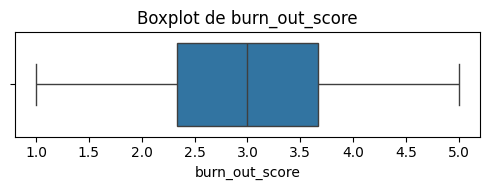

In [173]:
# --------------------------------------------
# BOXPLOTS (OUTLIERS)
# --------------------------------------------
for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

### 4.2 Análisis Bivariante

## 5. Modelos Predictivos

### A. Modelo de clasificación.

B. Modelo de regresión

## 6. Modelo Avanzado

A. Uno de estos:

- Modelo multiclase.
- Modelo ensemble.
- Red neuronal.
- Modelo temporal.
- Sistema de recomendación.
- Pipeline automatizado.

## 7. Análisis No Supervisado o Segmentación

### Aplicar al menos una técnica no supervisada:
- Clustering.
- Reducción de dimensionalidad.
- Segmentación de usuarios o entidades.